In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import (f1_score, recall_score, precision_score,
                             accuracy_score, roc_auc_score, confusion_matrix, roc_auc_score, classification_report)
import joblib

X_train = pd.read_csv('X_train.csv')
X_test  = pd.read_csv('X_test.csv')
y_train = pd.read_csv('y_train.csv').squeeze()
y_test  = pd.read_csv('y_test.csv').squeeze()

print(f"X_train: {X_train.shape} | X_test: {X_test.shape}")

X_train: (734, 16) | X_test: (184, 16)


In [4]:
kernels = {
    'SVM-RBF':        SVC(kernel='rbf',    C=1.0, gamma='scale', probability=True, random_state=42),
    'SVM-Linear':     SVC(kernel='linear', C=1.0, probability=True, random_state=42),
    'SVM-Polynomial': SVC(kernel='poly',   C=1.0, degree=3, coef0=1, probability=True, random_state=42),
}

results = {}
for name, model in kernels.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    results[name] = {
        'Accuracy':  round(accuracy_score(y_test, y_pred), 4),
        'Precision': round(precision_score(y_test, y_pred), 4),
        'Recall':    round(recall_score(y_test, y_pred), 4),
        'F1':        round(f1_score(y_test, y_pred), 4),
        'ROC-AUC':   round(roc_auc_score(y_test, y_prob), 4),
    }
    print(f"\n{'='*40}\n{name}")
    print(classification_report(y_test, y_pred, target_names=['No Disease','Disease']))


SVM-RBF
              precision    recall  f1-score   support

  No Disease       0.92      0.83      0.87        82
     Disease       0.87      0.94      0.91       102

    accuracy                           0.89       184
   macro avg       0.90      0.89      0.89       184
weighted avg       0.89      0.89      0.89       184


SVM-Linear
              precision    recall  f1-score   support

  No Disease       0.88      0.83      0.86        82
     Disease       0.87      0.91      0.89       102

    accuracy                           0.88       184
   macro avg       0.88      0.87      0.87       184
weighted avg       0.88      0.88      0.87       184


SVM-Polynomial
              precision    recall  f1-score   support

  No Disease       0.86      0.84      0.85        82
     Disease       0.88      0.89      0.88       102

    accuracy                           0.87       184
   macro avg       0.87      0.87      0.87       184
weighted avg       0.87      0.87    

In [5]:
param_grid = {
    'C':     [0.1, 1, 10, 100],
    'gamma': ['scale', 'auto', 0.001, 0.01, 0.1],
}

grid_search = GridSearchCV(
    SVC(kernel='rbf', probability=True, random_state=42),
    param_grid,
    cv=5,
    scoring='f1_macro',
    n_jobs=-1,
    verbose=1,
)
grid_search.fit(X_train, y_train)

print(f"\nBest params : {grid_search.best_params_}")
print(f"Best CV F1  : {grid_search.best_score_:.4f}")

best_svm  = grid_search.best_estimator_
y_pred_b  = best_svm.predict(X_test)
y_prob_b  = best_svm.predict_proba(X_test)[:, 1]

results['SVM-RBF-Tuned'] = {
    'Accuracy':  round(accuracy_score(y_test, y_pred_b), 4),
    'Precision': round(precision_score(y_test, y_pred_b), 4),
    'Recall':    round(recall_score(y_test, y_pred_b), 4),
    'F1':        round(f1_score(y_test, y_pred_b), 4),
    'ROC-AUC':   round(roc_auc_score(y_test, y_prob_b), 4),
}
print("\nSVM-RBF-Tuned:")
print(classification_report(y_test, y_pred_b, target_names=['No Disease','Disease']))

Fitting 5 folds for each of 20 candidates, totalling 100 fits

Best params : {'C': 100, 'gamma': 0.001}
Best CV F1  : 0.8667

SVM-RBF-Tuned:
              precision    recall  f1-score   support

  No Disease       0.89      0.83      0.86        82
     Disease       0.87      0.92      0.90       102

    accuracy                           0.88       184
   macro avg       0.88      0.88      0.88       184
weighted avg       0.88      0.88      0.88       184



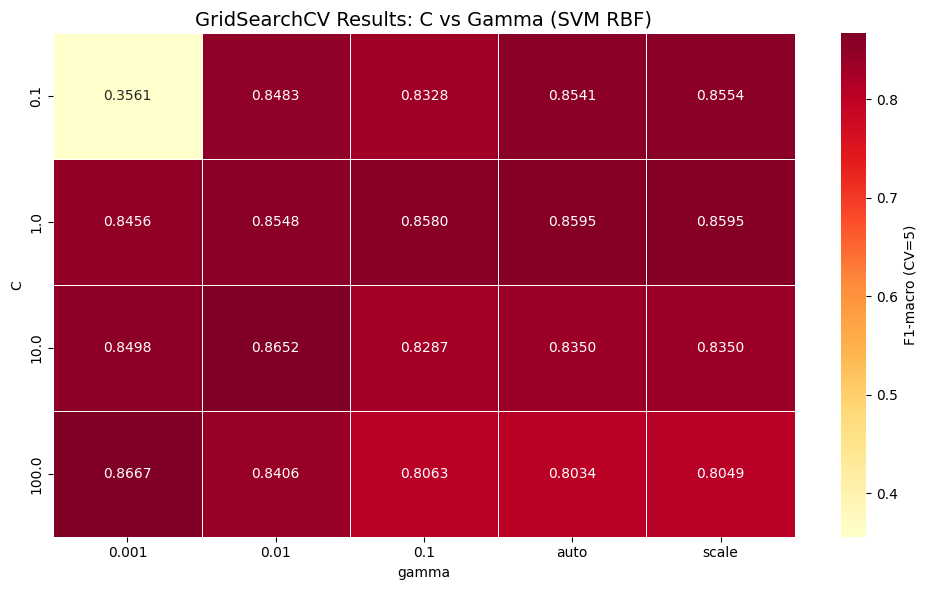

✅ gridsearch_heatmap.png disimpan


In [6]:
cv_df = pd.DataFrame(grid_search.cv_results_)
pivot = cv_df.pivot_table(
    index='param_C', columns='param_gamma', values='mean_test_score'
)

plt.figure(figsize=(10, 6))
sns.heatmap(pivot, annot=True, fmt='.4f', cmap='YlOrRd',
            linewidths=0.5, cbar_kws={'label': 'F1-macro (CV=5)'})
plt.title('GridSearchCV Results: C vs Gamma (SVM RBF)', fontsize=14)
plt.xlabel('gamma')
plt.ylabel('C')
plt.tight_layout()
plt.savefig('gridsearch_heatmap.png', dpi=150)
plt.show()
print("✅ gridsearch_heatmap.png disimpan")

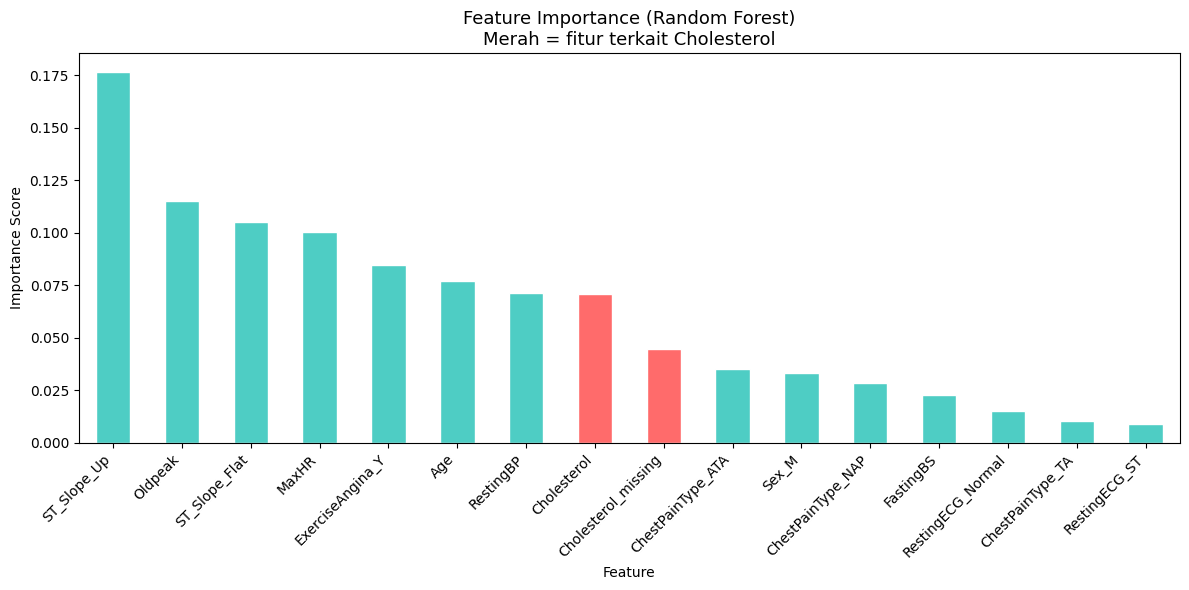

✅ feature_importance.png disimpan

Top 5 fitur:
ST_Slope_Up         0.176750
Oldpeak             0.115066
ST_Slope_Flat       0.104968
MaxHR               0.100617
ExerciseAngina_Y    0.084489
dtype: float64


In [7]:
rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
y_prob_rf  = rf.predict_proba(X_test)[:, 1]

results['RandomForest'] = {
    'Accuracy':  round(accuracy_score(y_test, y_pred_rf), 4),
    'Precision': round(precision_score(y_test, y_pred_rf), 4),
    'Recall':    round(recall_score(y_test, y_pred_rf), 4),
    'F1':        round(f1_score(y_test, y_pred_rf), 4),
    'ROC-AUC':   round(roc_auc_score(y_test, y_prob_rf), 4),
}

importances = pd.Series(rf.feature_importances_, index=X_train.columns)
importances_sorted = importances.sort_values(ascending=False)

plt.figure(figsize=(12, 6))
colors = ['#FF6B6B' if 'Cholesterol' in c else '#4ECDC4' for c in importances_sorted.index]
importances_sorted.plot(kind='bar', color=colors, edgecolor='white')
plt.title('Feature Importance (Random Forest)\nMerah = fitur terkait Cholesterol', fontsize=13)
plt.xlabel('Feature')
plt.ylabel('Importance Score')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150)
plt.show()
print("✅ feature_importance.png disimpan")
print("\nTop 5 fitur:")
print(importances_sorted.head())

In [8]:
df_results = pd.DataFrame(results).T[['Accuracy','Precision','Recall','F1','ROC-AUC']]
df_results = df_results.sort_values('F1', ascending=False)
print("\n=== Model Comparison ===")
print(df_results.to_string())

df_results.to_csv('model_comparison.csv')
joblib.dump(best_svm, 'svm_model.pkl')
joblib.dump(rf,       'rf_model.pkl')
print("\nmodel_comparison.csv, svm_model.pkl, rf_model.pkl disimpan")

# Verifikasi
m = joblib.load('svm_model.pkl')
assert m.predict(X_test.head(3)).shape == (3,)
print("Model load + predict: OK")


=== Model Comparison ===
                Accuracy  Precision  Recall      F1  ROC-AUC
SVM-RBF           0.8913     0.8727  0.9412  0.9057   0.9460
RandomForest      0.8913     0.9020  0.9020  0.9020   0.9385
SVM-RBF-Tuned     0.8804     0.8704  0.9216  0.8952   0.9375
SVM-Linear        0.8750     0.8692  0.9118  0.8900   0.9344
SVM-Polynomial    0.8696     0.8750  0.8922  0.8835   0.9293

model_comparison.csv, svm_model.pkl, rf_model.pkl disimpan
Model load + predict: OK


In [9]:
def evaluate(model, X, y):
    p  = model.predict(X)
    pr = model.predict_proba(X)[:, 1]
    tn, fp, fn, tp = confusion_matrix(y, p).ravel()
    return {
        'Accuracy':  round(accuracy_score(y, p), 4),
        'Precision': round(precision_score(y, p), 4),
        'Recall':    round(recall_score(y, p), 4),
        'F1':        round(f1_score(y, p), 4),
        'ROC-AUC':   round(roc_auc_score(y, pr), 4),
        'FN':        int(fn),
    }

results = {}
best_params = {}


svm_rbf_default = SVC(kernel='rbf', C=1.0, gamma='scale',
                      probability=True, random_state=42).fit(X_train, y_train)
results['SVM-RBF (default)'] = evaluate(svm_rbf_default, X_test, y_test)

grid_rbf = GridSearchCV(
    SVC(kernel='rbf', probability=True, random_state=42),
    {'C': [0.1, 1, 10, 100], 'gamma': ['scale', 'auto', 0.001, 0.01, 0.1]},
    cv=5, scoring='f1_macro', n_jobs=-1).fit(X_train, y_train)
results['SVM-RBF (tuned)'] = evaluate(grid_rbf.best_estimator_, X_test, y_test)
best_params['SVM-RBF'] = grid_rbf.best_params_


grid_lin = GridSearchCV(
    SVC(kernel='linear', probability=True, random_state=42),
    {'C': [0.01, 0.1, 1, 10, 100]},
    cv=5, scoring='f1_macro', n_jobs=-1).fit(X_train, y_train)
results['SVM-Linear (tuned)'] = evaluate(grid_lin.best_estimator_, X_test, y_test)
best_params['SVM-Linear'] = grid_lin.best_params_


grid_poly = GridSearchCV(
    SVC(kernel='poly', probability=True, random_state=42),
    {'C': [0.1, 1, 10], 'degree': [2, 3, 4], 'coef0': [0, 1], 'gamma': ['scale', 'auto']},
    cv=5, scoring='f1_macro', n_jobs=-1).fit(X_train, y_train)
results['SVM-Poly (tuned)'] = evaluate(grid_poly.best_estimator_, X_test, y_test)
best_params['SVM-Poly'] = grid_poly.best_params_


grid_lr = GridSearchCV(
    LogisticRegression(max_iter=5000, random_state=42),
    {'C': [0.01, 0.1, 1, 10, 100]},
    cv=5, scoring='f1_macro', n_jobs=-1).fit(X_train, y_train)
results['LR (tuned)'] = evaluate(grid_lr.best_estimator_, X_test, y_test)
best_params['LR'] = grid_lr.best_params_


grid_rf = GridSearchCV(
    RandomForestClassifier(random_state=42, n_jobs=-1),
    {'n_estimators': [100, 200], 'max_depth': [5, 10, None],
     'min_samples_split': [2, 5], 'max_features': ['sqrt', 'log2']},
    cv=5, scoring='f1_macro', n_jobs=-1).fit(X_train, y_train)
results['RF (tuned)'] = evaluate(grid_rf.best_estimator_, X_test, y_test)
best_params['RF'] = grid_rf.best_params_


df_results = pd.DataFrame(results).T[['Accuracy', 'Precision', 'Recall', 'F1', 'ROC-AUC', 'FN']]
df_results = df_results.sort_values('F1', ascending=False)
print("=== Model Comparison (semua model di-tune, fair) ===")
print(df_results.to_string())

print("\n=== Best Hyperparameters ===")
for model, params in best_params.items():
    print(f"  {model:<12}: {params}")


df_results.to_csv('model_comparison.csv')

# Model yang di-DEPLOY tetap SVM-RBF default (AUC & FN terbaik)
joblib.dump(svm_rbf_default, 'svm_model.pkl')
joblib.dump(grid_rf.best_estimator_, 'rf_model.pkl')
print("\n✅ model_comparison.csv, svm_model.pkl, rf_model.pkl disimpan")

# Verifikasi
m = joblib.load('svm_model.pkl')
assert m.predict(X_test.head(3)).shape == (3,)
print("✅ Model load + predict: OK")

=== Model Comparison (semua model di-tune) ===
                    Accuracy  Precision  Recall      F1  ROC-AUC    FN
LR (tuned)            0.8967     0.8952  0.9216  0.9082   0.9347   8.0
SVM-RBF (default)     0.8913     0.8727  0.9412  0.9057   0.9460   6.0
SVM-Poly (tuned)      0.8913     0.8868  0.9216  0.9038   0.9376   8.0
RF (tuned)            0.8859     0.8932  0.9020  0.8976   0.9346  10.0
SVM-RBF (tuned)       0.8804     0.8704  0.9216  0.8952   0.9375   8.0
SVM-Linear (tuned)    0.8804     0.8704  0.9216  0.8952   0.9372   8.0

=== Best Hyperparameters ===
  SVM-RBF     : {'C': 100, 'gamma': 0.001}
  SVM-Linear  : {'C': 0.1}
  SVM-Poly    : {'C': 0.1, 'coef0': 1, 'degree': 3, 'gamma': 'scale'}
  LR          : {'C': 0.1}
  RF          : {'max_depth': 10, 'max_features': 'sqrt', 'min_samples_split': 2, 'n_estimators': 200}

✅ model_comparison.csv, svm_model.pkl, rf_model.pkl disimpan
✅ Model load + predict: OK
